In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('../data/imputed_data/gurgaon_properties_missing_value_imputation.csv')

In [5]:
df.shape

(3554, 18)

In [6]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flats,breez global hill view,sohna road,0.35,6318.0,2,2,2,14.0,New Property,616.0,0,0,0,0,0,1,53
1,flats,tulip violet,sector 69,1.65,8871.0,3,3,2,1.0,Relatively New,1578.0,0,0,0,0,0,0,69
2,house,suncity township,sector 54,25.00,31110.0,4,4,3+,2.0,Moderately Old,8036.0,0,0,0,0,0,1,0
3,flats,shree vardhman victoria,sector 70,1.75,8974.0,3,5,0,0.0,Relatively New,1950.0,0,0,0,0,0,1,47
4,flats,adani aangan galleria,sector 89,0.25,5000.0,1,1,1,6.0,New Property,430.0,0,0,0,0,0,1,74


In [7]:
#we are removing these two columns since we are not going to ask our user about the type of society and price per sqft
train_df = df.drop(columns=['society','price_per_sqft'])

In [8]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flats,sohna road,0.35,2,2,2,14.0,New Property,616.0,0,0,0,0,0,1,53
1,flats,sector 69,1.65,3,3,2,1.0,Relatively New,1578.0,0,0,0,0,0,0,69
2,house,sector 54,25.00,4,4,3+,2.0,Moderately Old,8036.0,0,0,0,0,0,1,0
3,flats,sector 70,1.75,3,5,0,0.0,Relatively New,1950.0,0,0,0,0,0,1,47
4,flats,sector 89,0.25,1,1,1,6.0,New Property,430.0,0,0,0,0,0,1,74


luxury score

<Axes: ylabel='luxury_score'>

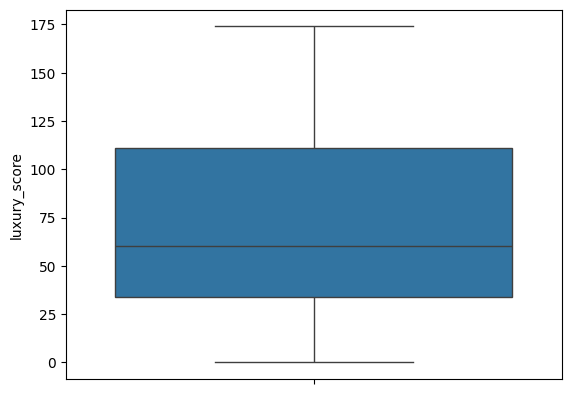

In [9]:
#converting this column to categorical: budget, semi luxury, luxury
sns.boxplot(df['luxury_score'])

In [10]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [11]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [12]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flats,sohna road,0.35,2,2,2,14.0,New Property,616.0,0,0,0,0,0,1,53,Medium
1,flats,sector 69,1.65,3,3,2,1.0,Relatively New,1578.0,0,0,0,0,0,0,69,Medium
2,house,sector 54,25.00,4,4,3+,2.0,Moderately Old,8036.0,0,0,0,0,0,1,0,Low
3,flats,sector 70,1.75,3,5,0,0.0,Relatively New,1950.0,0,0,0,0,0,1,47,Low
4,flats,sector 89,0.25,1,1,1,6.0,New Property,430.0,0,0,0,0,0,1,74,Medium


floorNum

<Axes: ylabel='floorNum'>

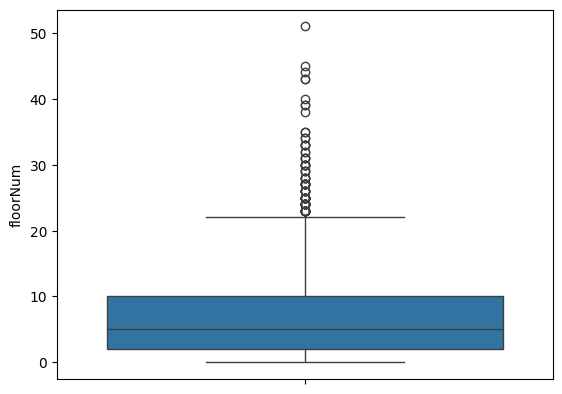

In [13]:
#converting this column into categorical too: low medium high 
sns.boxplot(df['floorNum'])

In [14]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [15]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [16]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flats,sohna road,0.35,2,2,2,14.0,New Property,616.0,0,0,0,0,0,1,53,Medium,High Floor
1,flats,sector 69,1.65,3,3,2,1.0,Relatively New,1578.0,0,0,0,0,0,0,69,Medium,Low Floor
2,house,sector 54,25.00,4,4,3+,2.0,Moderately Old,8036.0,0,0,0,0,0,1,0,Low,Low Floor
3,flats,sector 70,1.75,3,5,0,0.0,Relatively New,1950.0,0,0,0,0,0,1,47,Low,Low Floor
4,flats,sector 89,0.25,1,1,1,6.0,New Property,430.0,0,0,0,0,0,1,74,Medium,Mid Floor


In [17]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [18]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flats,sohna road,0.35,2,2,2,New Property,616.0,0,0,0,0,0,1,Medium,High Floor
1,flats,sector 69,1.65,3,3,2,Relatively New,1578.0,0,0,0,0,0,0,Medium,Low Floor
2,house,sector 54,25.00,4,4,3+,Moderately Old,8036.0,0,0,0,0,0,1,Low,Low Floor
3,flats,sector 70,1.75,3,5,0,Relatively New,1950.0,0,0,0,0,0,1,Low,Low Floor
4,flats,sector 89,0.25,1,1,1,New Property,430.0,0,0,0,0,0,1,Medium,Mid Floor


In [19]:
#converting categorical column into numbers
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flats', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 17a', 'sector 17b', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 36a', 'sector 37', 'sector 37c',
       'sector 37d', 'sector 38', 'sector 39', 'sector 4', 'sector 40',
       'sector 41', 'sector 43', 'sector 45', 'sector 46', 'sector 47',
       'sector 48', 'sector 49', 'sector 5', 'sector 50', 'sector 51',
       'sector 52', 'sec

In [20]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,113.0,2,2,2.0,1.0,616.0,0,0,0,0,0,1,2.0,0.0
1,0.0,80.0,3,3,2.0,3.0,1578.0,0,0,0,0,0,0,2.0,1.0
2,1.0,63.0,4,4,4.0,0.0,8036.0,0,0,0,0,0,1,1.0,1.0
3,0.0,82.0,3,5,0.0,3.0,1950.0,0,0,0,0,0,1,1.0,1.0
4,0.0,103.0,1,1,1.0,1.0,430.0,0,0,0,0,0,1,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,1.0,69.0,4,2,2.0,0.0,1600.0,0,0,0,0,0,1,1.0,1.0
3550,0.0,8.0,2,2,1.0,3.0,514.0,0,0,0,0,0,1,2.0,2.0
3551,0.0,85.0,3,3,3.0,3.0,1975.0,0,0,0,0,0,1,1.0,2.0
3552,0.0,109.0,1,1,1.0,3.0,3569.0,0,0,0,0,0,1,1.0,0.0


In [21]:
y_label

0        0.35
1        1.65
2       25.00
3        1.75
4        0.25
        ...  
3549     0.40
3550     0.40
3551     1.90
3552     0.19
3553     0.90
Name: price, Length: 3554, dtype: float64

technique-1: correlation analysis

<Axes: >

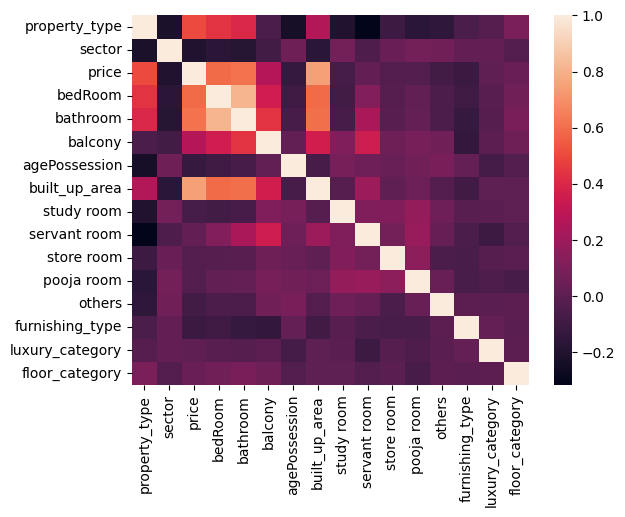

In [22]:
sns.heatmap(data_label_encoded.corr())

In [23]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.199775
1,price,1.000000
2,bedRoom,0.591471
3,bathroom,0.609777
4,balcony,0.269637
5,agePossession,-0.129295
6,built_up_area,0.744312
7,study room,-0.069980
8,servant room,0.021027
9,store room,-0.028423


technique-2: Random forest importance

In [24]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.647907
1,sector,0.116541
0,property_type,0.106527
3,bathroom,0.034648
2,bedRoom,0.032040
5,agePossession,0.015820
4,balcony,0.013901
12,furnishing_type,0.011597
13,luxury_category,0.010363
14,floor_category,0.006101


technique-3: gradient boosting feature imporatnaces

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.689143
1,sector,0.108939
0,property_type,0.103215
2,bedRoom,0.041196
3,bathroom,0.037975
13,luxury_category,0.006661
5,agePossession,0.005910
4,balcony,0.002982
12,furnishing_type,0.001809
14,floor_category,0.001360


technique-4: permutation imporatnce

In [26]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.725020
0,property_type,0.159693
1,sector,0.148056
2,bedRoom,0.005421
12,furnishing_type,0.001597
8,servant room,0.001028
11,others,0.000462
9,store room,0.000009
7,study room,-0.000092
10,pooja room,-0.000102


technique-5: lasso(linear model are not that much reliable since we did ordinal encoding)

In [27]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.606305
0,property_type,0.738851
3,bathroom,0.417358
4,balcony,0.054585
13,luxury_category,0.021651
7,study room,0.018214
2,bedRoom,0.003415
14,floor_category,-0.000000
9,store room,0.000000
5,agePossession,-0.023656


technique-6: recursive feature elimination

In [28]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6


,feature,rfe_score
6,built_up_area,0.646106
1,sector,0.115708
0,property_type,0.108795
3,bathroom,0.034305
2,bedRoom,0.031552
5,agePossession,0.016820
4,balcony,0.014646
12,furnishing_type,0.011393
13,luxury_category,0.009466
14,floor_category,0.006476


technique-7: linear regression weights

In [29]:
from sklearn.linear_model import LinearRegression
# Train a linear regression model on the label-encoded and standardized training data
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.610052
0,property_type,0.737608
3,bathroom,0.423436
4,balcony,0.064371
7,study room,0.032681
13,luxury_category,0.029521
2,bedRoom,0.003843
9,store room,0.000074
14,floor_category,-0.009803
5,agePossession,-0.031337


In [32]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').set_index('feature')

In [33]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs
feature,,,,,,,
sector,-0.199775,0.116541,0.108939,0.148056,-0.035731,0.115708,-0.043730
bedRoom,0.591471,0.032040,0.041196,0.005421,0.003415,0.031552,0.003843
bathroom,0.609777,0.034648,0.037975,-0.003730,0.417358,0.034305,0.423436
balcony,0.269637,0.013901,0.002982,-0.001194,0.054585,0.014646,0.064371
agePossession,-0.129295,0.015820,0.005910,-0.007044,-0.023656,0.016820,-0.031337
built_up_area,0.744312,0.647907,0.689143,0.725020,1.606305,0.646106,1.610052
study room,-0.069980,0.000982,0.000000,-0.000092,0.018214,0.001052,0.032681
servant room,0.021027,0.001398,0.000692,0.001028,-0.129666,0.001629,-0.145083
store room,-0.028423,0.000414,0.000117,0.000009,0.000000,0.000378,0.000074


In [34]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [35]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.764354
sector             0.138261
bedRoom            0.030868
bathroom           0.028826
agePossession      0.008755
balcony            0.008484
furnishing_type    0.007407
luxury_category    0.006137
floor_category     0.003702
servant room       0.001339
others             0.000621
study room         0.000543
pooja room         0.000445
store room         0.000257
dtype: float64

In [36]:
# to drop pooja room, study room, others
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,113.0,2,2,2.0,1.0,616.0,0,0,0,0,0,1,2.0,0.0
1,0.0,80.0,3,3,2.0,3.0,1578.0,0,0,0,0,0,0,2.0,1.0
2,1.0,63.0,4,4,4.0,0.0,8036.0,0,0,0,0,0,1,1.0,1.0
3,0.0,82.0,3,5,0.0,3.0,1950.0,0,0,0,0,0,1,1.0,1.0
4,0.0,103.0,1,1,1.0,1.0,430.0,0,0,0,0,0,1,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,1.0,69.0,4,2,2.0,0.0,1600.0,0,0,0,0,0,1,1.0,1.0
3550,0.0,8.0,2,2,1.0,3.0,514.0,0,0,0,0,0,1,2.0,2.0
3551,0.0,85.0,3,3,3.0,3.0,1975.0,0,0,0,0,0,1,1.0,2.0
3552,0.0,109.0,1,1,1.0,3.0,3569.0,0,0,0,0,0,1,1.0,0.0


In [39]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [40]:
scores.mean()

np.float64(0.7916061460800521)

In [41]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [42]:
scores.mean()

np.float64(0.7915064361688271)

In [43]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [44]:
export_df.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,113.0,2,2,2.0,1.0,616.0,0,0,1,2.0,0.0,0.35
1,0.0,80.0,3,3,2.0,3.0,1578.0,0,0,0,2.0,1.0,1.65
2,1.0,63.0,4,4,4.0,0.0,8036.0,0,0,1,1.0,1.0,25.00
3,0.0,82.0,3,5,0.0,3.0,1950.0,0,0,1,1.0,1.0,1.75
4,0.0,103.0,1,1,1.0,1.0,430.0,0,0,1,2.0,2.0,0.25


In [45]:
import os
data_path=os.path.join('..','data','post_feature_selection_data')
os.makedirs(data_path)
export_df.to_csv(os.path.join(data_path,'gurgaon_properties_post_feature_selection.csv'),index=False)